# 02 — Feed-forward propagation, unit by unit, on a real sample

We now connect neurons into a network. We will use the same four real image-derived features and a tiny architecture:

**4 inputs → 3 hidden neurons → 1 output neuron**.

## What you should learn
- the exact scalar arithmetic inside every hidden neuron;
- how scalar arithmetic and matrix multiplication are the same computation;
- tensor shapes at every stage;
- why a hidden layer is a *new representation* of the input;
- how changing one input or one weight propagates downstream.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
d=load_digits(); img=d.images[3]; digit=int(d.target[3])
x=np.array([img[:4,:].sum(),img[4:,:].sum(),img[:,:4].sum(),img[:,4:].sum()],dtype=float).reshape(1,-1)
feature_names=['top','bottom','left','right']
W1=np.array([[ .020,-.010,.015],[-.030,.050,.010],[.010,.020,-.040],[.040,-.020,.030]])
b1=np.array([[.10,-.20,.05]])
W2=np.array([[1.20],[-.90],[.70]])
b2=np.array([[.05]])
print('digit:',digit,'x shape:',x.shape,'W1:',W1.shape,'b1:',b1.shape,'W2:',W2.shape,'b2:',b2.shape)


digit: 3 x shape: (1, 4) W1: (4, 3) b1: (1, 3) W2: (3, 1) b2: (1, 1)


## 1. Hidden neuron 1 manually
For the first hidden unit:

$$z^{(1)}_1=x_1W_{11}+x_2W_{21}+x_3W_{31}+x_4W_{41}+b_1$$


In [2]:
manual_terms=x.ravel()*W1[:,0]
manual_z1_h1=manual_terms.sum()+b1[0,0]
manual_a1_h1=np.tanh(manual_z1_h1)
pd.DataFrame({'feature':feature_names,'x':x.ravel(),'weight→h1':W1[:,0],'contribution':manual_terms})


,feature,x,weight→h1,contribution
0,top,140.0,0.02,2.80
1,bottom,127.0,-0.03,-3.81
2,left,115.0,0.01,1.15
3,right,152.0,0.04,6.08


In [3]:
print('manual z_h1 =',manual_z1_h1)
print('manual tanh(z_h1) =',manual_a1_h1)


manual z_h1 = 6.32
manual tanh(z_h1) = 0.9999935204277413


## 2. Compute all hidden neurons at once

$$\mathbf z^{(1)}=\mathbf xW^{(1)}+\mathbf b^{(1)}$$


In [4]:
z1=x@W1+b1
a1=np.tanh(z1)
z2=a1@W2+b2
yhat=1/(1+np.exp(-z2))
assert np.allclose(z1[0,0],manual_z1_h1)
print('z1 =',z1)
print('a1 =',a1)
print('z2 =',z2)
print('yhat =',yhat)
shape_ledger=pd.DataFrame([
 ['x',x.shape,'real input features'],['W1',W1.shape,'input→hidden parameters'],['z1',z1.shape,'hidden pre-activations'],['a1',a1.shape,'hidden representation'],['W2',W2.shape,'hidden→output parameters'],['yhat',yhat.shape,'output score']
],columns=['tensor','shape','meaning']);shape_ledger


z1 = [[6.32 4.01 3.38]]
a1 = [[0.99999 0.99934 0.99768]]
z2 = [[1.04896]]
yhat = [[0.74058]]


,tensor,shape,meaning
0,x,"(1, 4)",real input features
1,W1,"(4, 3)",input→hidden parameters
2,z1,"(1, 3)",hidden pre-activations
3,a1,"(1, 3)",hidden representation
4,W2,"(3, 1)",hidden→output parameters
5,yhat,"(1, 1)",output score


### Why $a^{(1)}$ is called a representation
The original sample was described by four measurements. After the hidden layer it is described by **three learned coordinates**. Those coordinates need not look like human-engineered concepts; they are whatever coordinates make the downstream objective easier to solve.


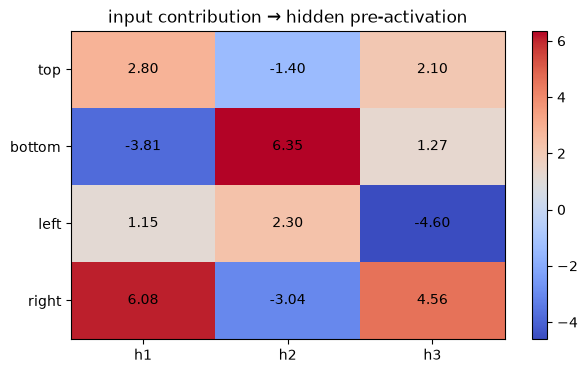

In [5]:
# Contribution heatmap: each input's signed contribution to each hidden neuron
contrib_matrix=x.reshape(-1,1)*W1
fig,ax=plt.subplots(figsize=(7,4))
im=ax.imshow(contrib_matrix,cmap='coolwarm',aspect='auto')
ax.set_xticks(range(3),['h1','h2','h3']);ax.set_yticks(range(4),feature_names)
for i in range(4):
    for j in range(3): ax.text(j,i,f'{contrib_matrix[i,j]:.2f}',ha='center',va='center')
ax.set_title('input contribution → hidden pre-activation');plt.colorbar(im,ax=ax);plt.show()


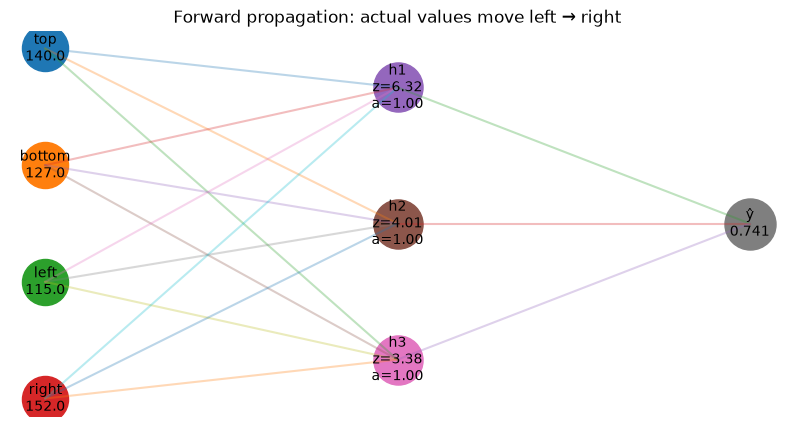

In [6]:
def draw_network(xv,hv,outv):
    fig,ax=plt.subplots(figsize=(10,5))
    xin=[(0,1.8),(0,.6),(0,-.6),(0,-1.8)]
    hid=[(2,1.4),(2,0),(2,-1.4)]; out=(4,0)
    for i,p in enumerate(xin):
        ax.scatter(*p,s=1100);ax.text(*p,f'{feature_names[i]}\n{xv[i]:.1f}',ha='center',va='center')
    for j,p in enumerate(hid):
        ax.scatter(*p,s=1250);ax.text(*p,f'h{j+1}\nz={z1[0,j]:.2f}\na={hv[j]:.2f}',ha='center',va='center')
    ax.scatter(*out,s=1350);ax.text(*out,f'ŷ\n{outv:.3f}',ha='center',va='center')
    for p1 in xin:
        for p2 in hid: ax.plot([p1[0],p2[0]],[p1[1],p2[1]],alpha=.3)
    for p1 in hid: ax.plot([p1[0],out[0]],[p1[1],out[1]],alpha=.3)
    ax.axis('off');ax.set_title('Forward propagation: actual values move left → right');plt.show()
draw_network(x.ravel(),a1.ravel(),yhat.item())


## 3. What affects what? Perturb one real input
A change in one feature affects **all hidden neurons that connect to it**, then the output combines those changed hidden values.


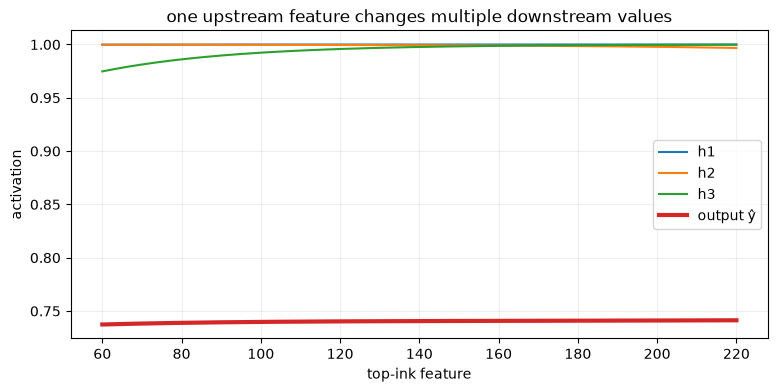

In [7]:
vals=np.linspace(max(0,x[0,0]-80),x[0,0]+80,200)
Hs=[];Ys=[]
for v in vals:
    xx=x.copy();xx[0,0]=v
    hh=np.tanh(xx@W1+b1);yy=1/(1+np.exp(-(hh@W2+b2)))
    Hs.append(hh.ravel());Ys.append(yy.item())
Hs=np.array(Hs)
fig,ax=plt.subplots(figsize=(9,4))
for j in range(3): ax.plot(vals,Hs[:,j],label=f'h{j+1}')
ax.plot(vals,Ys,label='output ŷ',lw=3)
ax.set_xlabel('top-ink feature');ax.set_ylabel('activation');ax.legend();ax.grid(alpha=.2);ax.set_title('one upstream feature changes multiple downstream values');plt.show()


## Inference / insight
Forward propagation is deterministic given $(x,W,b)$. Nothing is learned *during* the forward pass. Learning happens only after the loss is computed and gradients update the parameters. The next notebook makes the loss visible.
